In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Creating a dummy Iris dataset

data = {
    "sepal_length": [5.1, 4.9, 6.2, 5.9, 6.7, 5.6, 5.5, 6.3, 4.8, 7.1,
                     5.0, 6.0, 6.1, 5.7, 6.8, 5.4, 4.7, 6.5, 5.8, 7.2],

    "sepal_width": [3.5, 3.0, 2.9, 3.2, 3.1, 2.8, 4.2, 3.3, 3.4, 3.0,
                    3.6, 2.7, 2.8, 4.4, 3.2, 3.9, 3.2, 3.0, 2.7, 3.6],

    "petal_length": [1.4, 1.4, 4.3, 5.1, 5.6, 4.9, 1.4, 6.0, 1.6, 5.9,
                     1.5, 4.5, 4.7, 1.5, 5.5, 1.7, 1.3, 5.8, 4.1, 6.1],

    "petal_width": [0.2, 0.2, 1.3, 1.8, 2.4, 2.0, 0.2, 2.5, 0.2, 2.1,
                    0.3, 1.5, 1.2, 0.4, 2.3, 0.4, 0.2, 2.2, 1.3, 2.5],

    "species": [
        "setosa", "setosa", "versicolor", "virginica", "virginica",
        "versicolor", "setosa", "virginica", "setosa", "virginica",
        "setosa", "versicolor", "versicolor", "setosa", "virginica",
        "setosa", "setosa", "virginica", "versicolor", "virginica"
    ]
}

df = pd.DataFrame(data)

# Display first 5 rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width     species
0           5.1          3.5           1.4          0.2      setosa
1           4.9          3.0           1.4          0.2      setosa
2           6.2          2.9           4.3          1.3  versicolor
3           5.9          3.2           5.1          1.8   virginica
4           6.7          3.1           5.6          2.4   virginica


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  20 non-null     float64
 1   sepal_width   20 non-null     float64
 2   petal_length  20 non-null     float64
 3   petal_width   20 non-null     float64
 4   species       20 non-null     object 
dtypes: float64(4), object(1)
memory usage: 932.0+ bytes
None
       sepal_length  sepal_width  petal_length  petal_width
count      20.00000    20.000000     20.000000    20.000000
mean        5.86500     3.275000      3.715000     1.260000
std         0.75622     0.476694      1.952401     0.916745
min         4.70000     2.700000      1.300000     0.200000
25%         5.32500     2.975000      1.500000     0.275000
50%         5.85000     3.200000      4.400000     1.300000
75%         6.35000     3.525000      5.525000     2.125000
max         7.20000     4.400000      6.100000     2.50

In [4]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


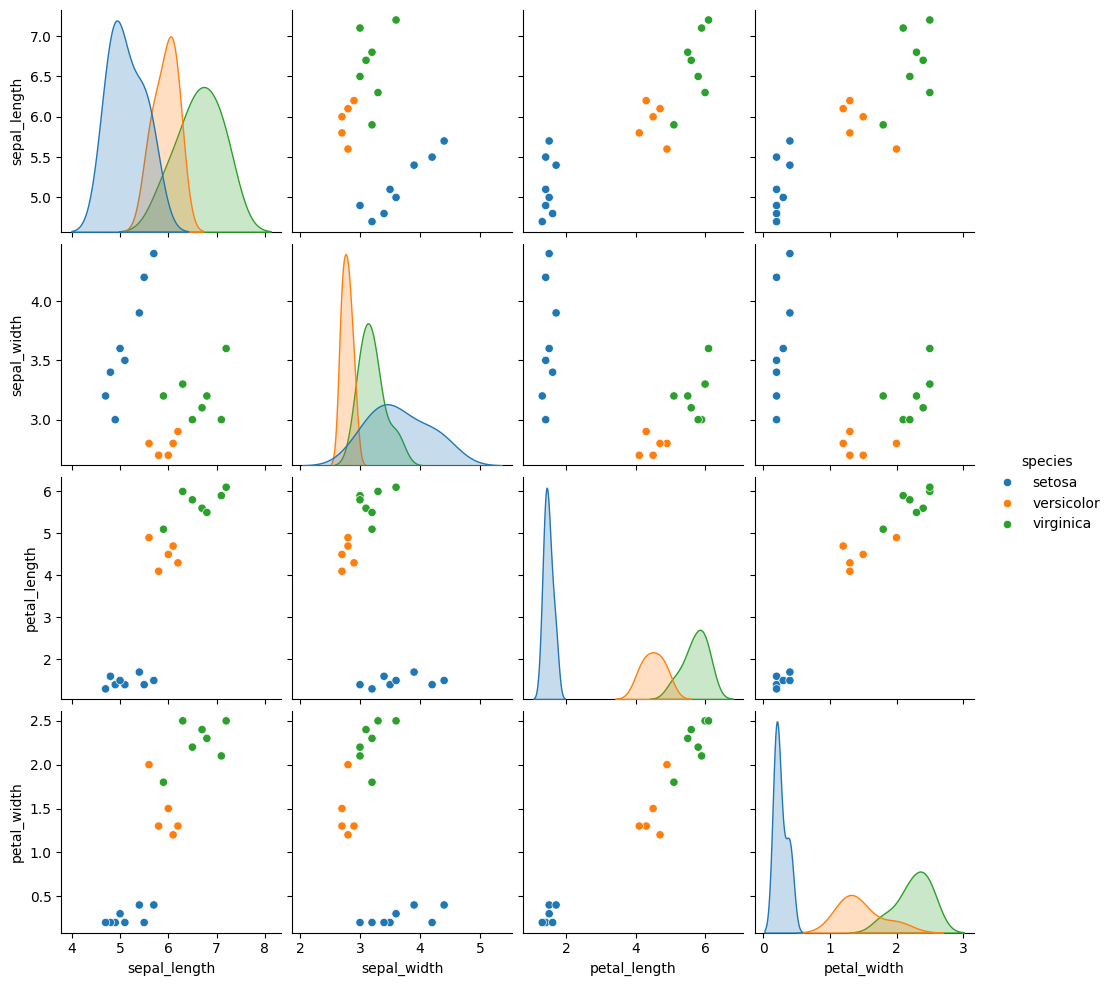

In [5]:
sns.pairplot(df, hue="species")
plt.show()

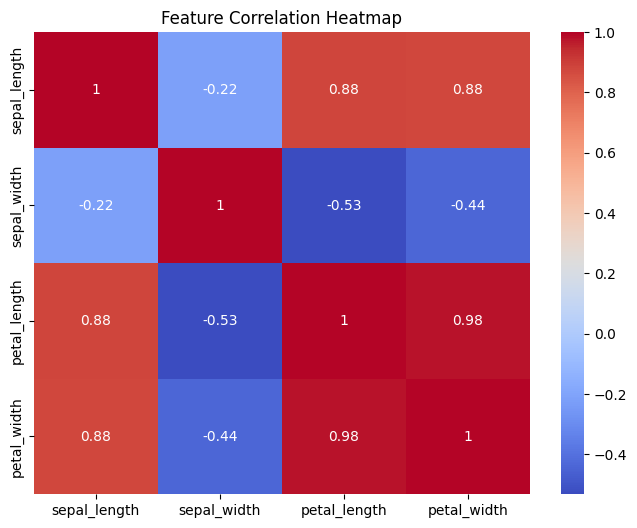

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Encode species labels

encoder = LabelEncoder()
df["species"] = encoder.fit_transform(df["species"])

# Features and target
X = df.drop("species", axis=1)
y = df["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16, 4)
Testing Data Shape: (4, 4)


In [8]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [10]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [11]:
def evaluate_model(model_name, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{model_name} Performance")
    print("-" * 30)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [12]:
evaluate_model("KNN", y_test, knn_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("SVM", y_test, svm_pred)


KNN Performance
------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Decision Tree Performance
------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


SVM Performance
------------------------------
Accuracy : 1.0
Precision: 

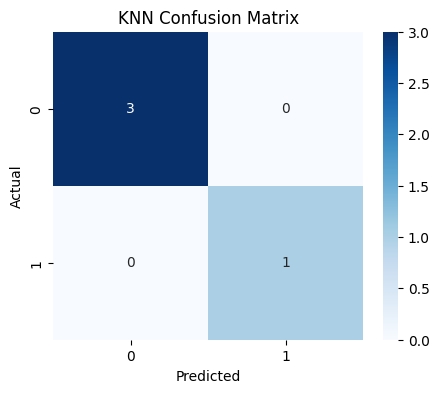

In [13]:
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

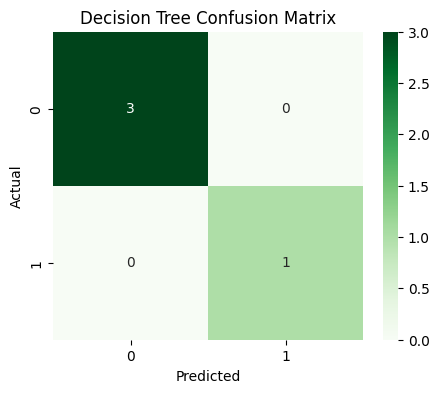

In [14]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

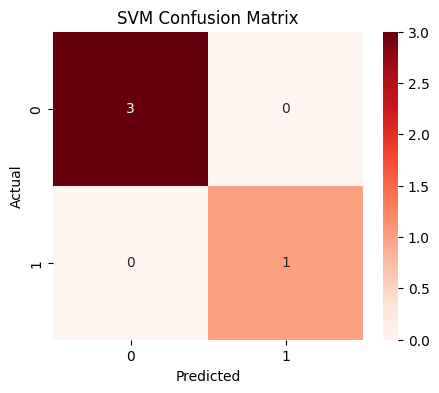

In [15]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# Example custom flower measurements

custom_input = [[5.1, 3.5, 1.4, 0.2]]

# Predict using SVM model
prediction = svm.predict(custom_input)

# Convert numeric label back to species name
species_name = encoder.inverse_transform(prediction)

print("Predicted Species:", species_name[0])

Predicted Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


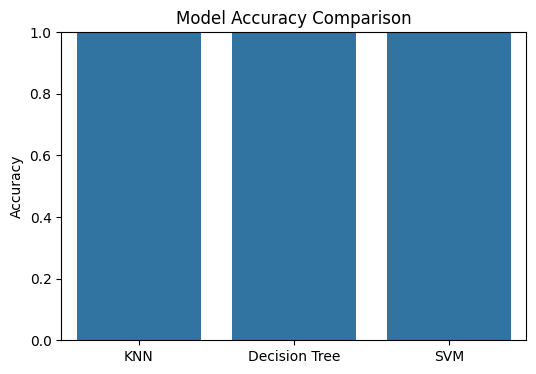

In [17]:
models = ["KNN", "Decision Tree", "SVM"]

accuracies = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()